# Prepare the env

I haven't found the solution to load config correclty without setting *os.chdir*, so you need to change the code below with path where the project is located. 

In [23]:
import os
import sys
os.chdir('/Users/zagrebinegor/Developer/ML_Wine_Quality')  # перейти из notebooks/ в корень проекта


In [41]:
from src.preprocess import get_preprocessor
from src.utils import load_config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [26]:
config = load_config('configs/baseline.yaml')

In [27]:
data = pd.read_csv('data/processed/X_train.csv')
labels = pd.read_csv('data/processed/y_train.csv')

# Understanding the data, assessing possible changes

Let's take a look at the target values. We'll find out what it is and what values ​​it lies between.

In [29]:
labels.describe()

,quality
count,914.000000
mean,5.656455
std,0.820151
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


We see that there are no empty values, the values ​​are located in the range from 3 to 8. Now let's look at the signs to better understand their essence.

In [30]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000
mean,8.258096,0.531018,0.265799,2.519092,0.086476,15.706783,45.838621,0.996683,3.314234,0.655646,10.439187,815.590810
std,1.696354,0.179047,0.194982,1.305725,0.047437,10.237482,31.929403,0.001914,0.152897,0.166146,1.074776,464.852449
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.400000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,412.250000
50%,7.900000,0.520000,0.250000,2.200000,0.078000,13.000000,38.000000,0.996645,3.310000,0.620000,10.200000,825.000000
75%,9.000000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.720000,11.200000,1219.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,1597.000000


In [ ]:
# data.isnull().sum()
# data.duplicated()

There's no null and duplicated rows so there's no need to use Imputer in *preprocess.py* and delete any duplicated rows. But I can see, that I need to delete Id column. 

Let's analyse some data to chose the operations to preprocess. I'm going to do preprocessing using the function from *preprocess.py* and compare the values ​​before processing with the resulting value.

In [ ]:
# Вычертить оригинал, написать пометку о логарифмических распределениях и что буду делать в preprocess.py
import matplotlib.pyplot as plt

for col in data.select_dtypes(include=['float64', 'int64']).columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма
    data[col].hist(bins=50, ax=axes[0])
    axes[0].set_title(f'{col} — distribution')
    
    # Box plot
    data.boxplot(column=col, ax=axes[1])
    axes[1].set_title(f'{col} — boxplot')
    
    plt.show()

After analyzing the feature distribution graphs, I noticed several important aspects:
1. Some features are not normally distributed.
2. The features have different scales.
3. There are almost no outliers; we'll ignore them for now.
4. Remove Id.

Based on this, we work with the feature distribution and their scale in preprocess.py.

# Comparison of processed and stock data

In [36]:
preprocessor = get_preprocessor(config)
X = data.drop('Id', axis=1)
X_processed = preprocessor.fit_transform(X)
scale_cols = config['preprocess']['scale_cols']
log_cols = config['preprocess']['log_cols']
processed_names = scale_cols + [f'{col}_log' for col in log_cols]
df_processed = pd.DataFrame(X_processed, columns=processed_names)


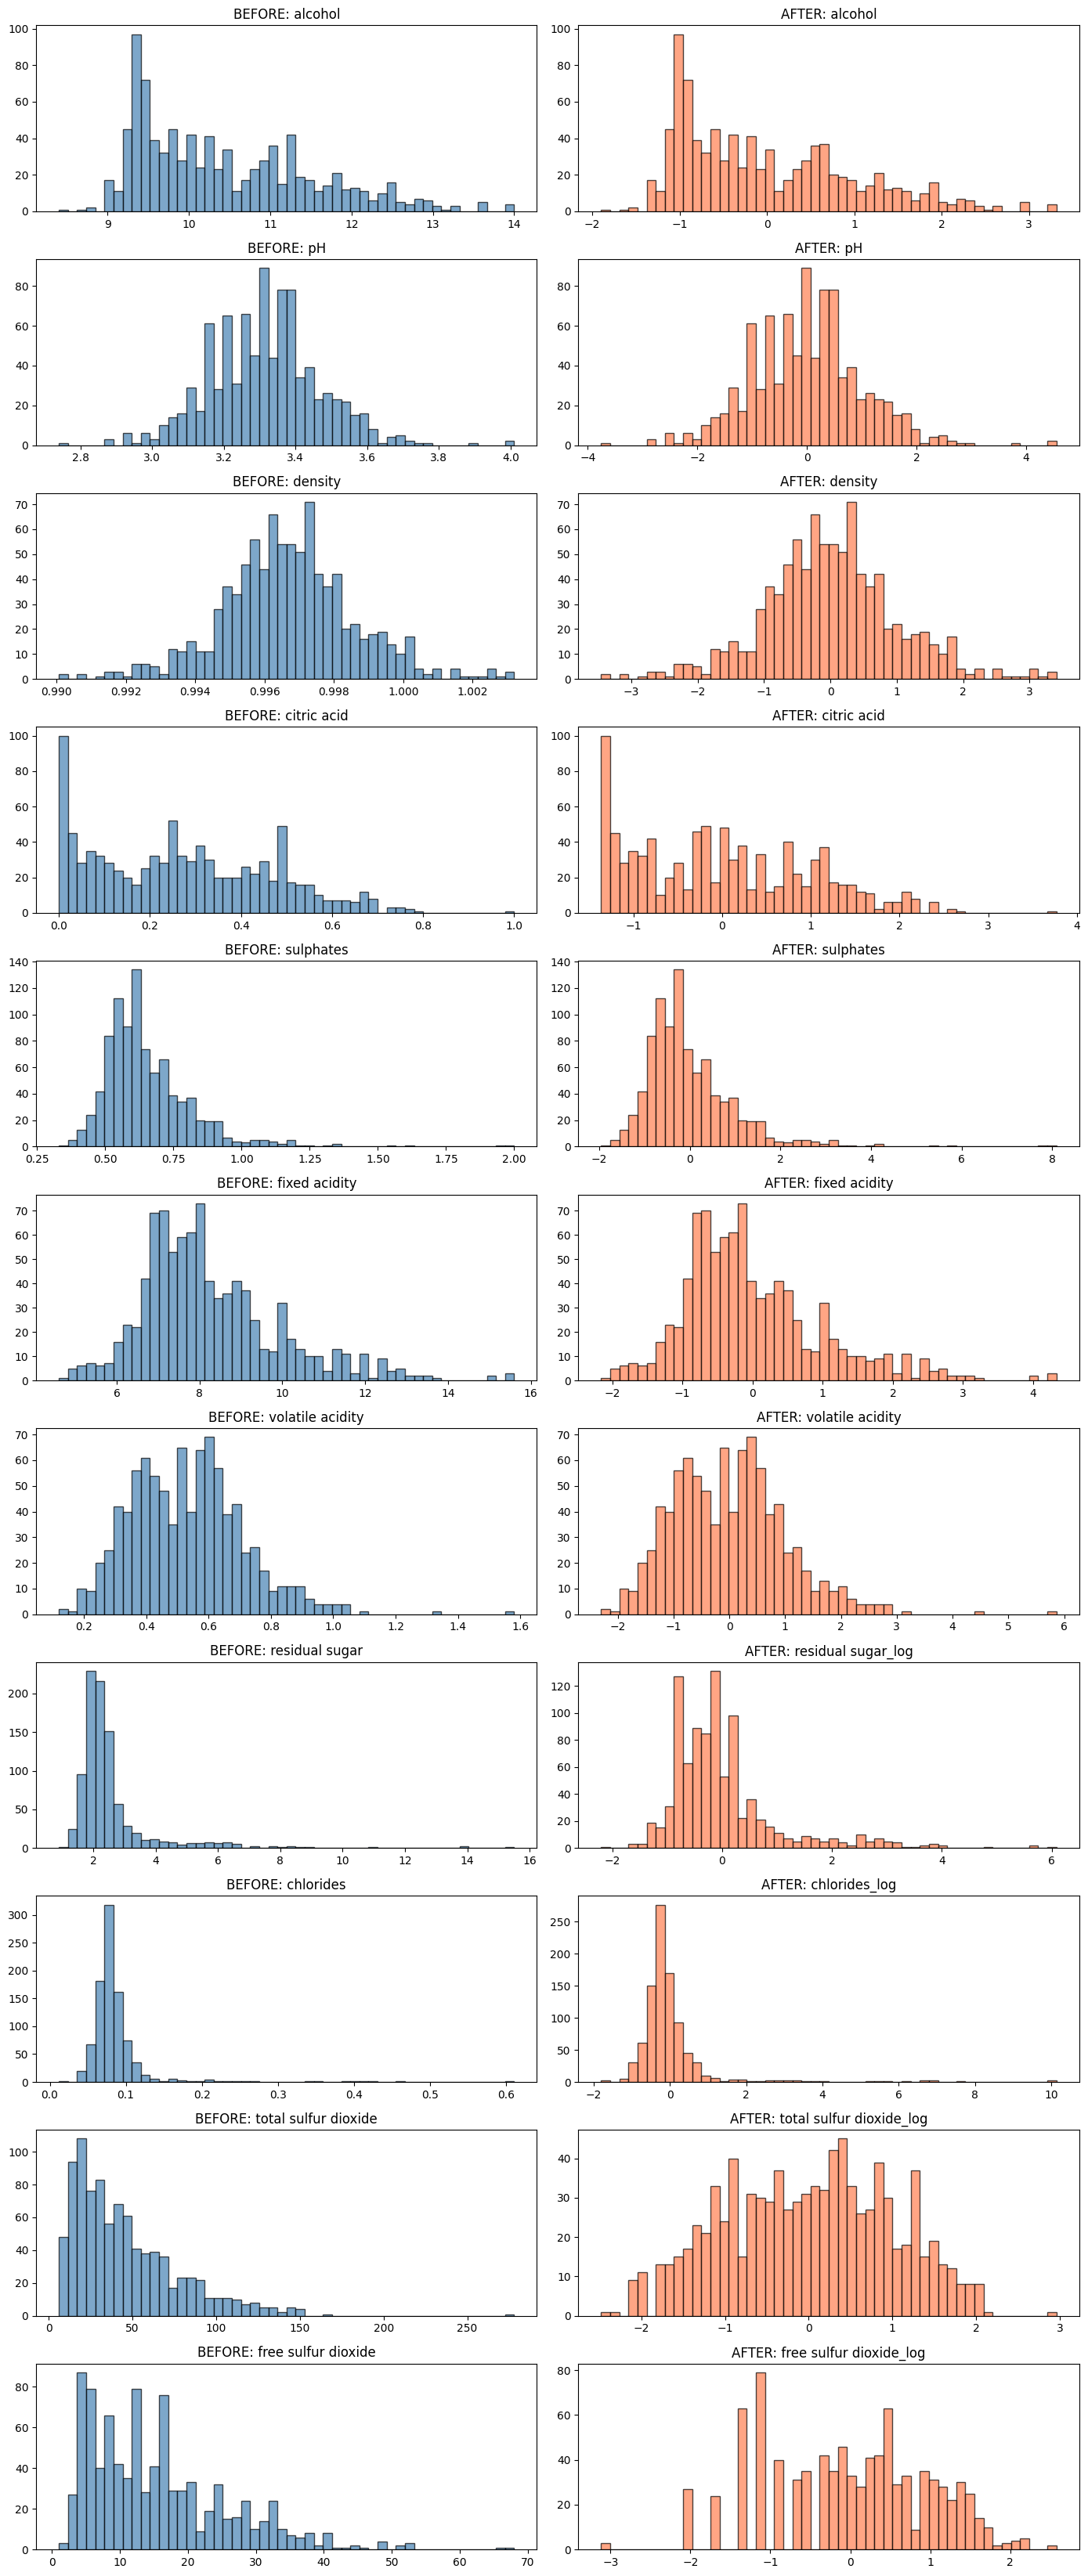

In [39]:
# Вычертить оригинал в сравненнии с препроцессом 
scale_cols = config['preprocess']['scale_cols']
log_cols = config['preprocess']['log_cols']

n_pairs = len(scale_cols) + len(log_cols)
fig, axes = plt.subplots(n_pairs, 2, figsize=(14, 3 * n_pairs))

idx = 0
# Масштабируемые колонки (имена не меняются)
for col in scale_cols:
    if col in data.columns and col in df_processed.columns:
        axes[idx, 0].hist(data[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 0].set_title(f'BEFORE: {col}')
        axes[idx, 1].hist(df_processed[col], bins=50, edgecolor='black', alpha=0.7, color='coral')
        axes[idx, 1].set_title(f'AFTER: {col}')
        idx += 1

# Логарифмируемые колонки (имена меняются)
for col in log_cols:
    col_after = f'{col}_log'
    if col in data.columns and col_after in df_processed.columns:
        axes[idx, 0].hist(data[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 0].set_title(f'BEFORE: {col}')
        axes[idx, 1].hist(df_processed[col_after], bins=50, edgecolor='black', alpha=0.7, color='coral')
        axes[idx, 1].set_title(f'AFTER: {col_after}')
        idx += 1

plt.tight_layout()
plt.show()

# Correlation Analisysis

Now let's look at the correlation between the features, as well as the dependencies between the features and the target.